# Feature Engineering for Electricity Price Forecasting

Transform raw data into powerful ML features that capture:
- **Temporal patterns** (hour, day, week, season)
- **Price dynamics** (lags, rolling stats, volatility)
- **Supply-demand balance** (renewable share, residual load)
- **Market interactions** (generation mix, weather correlations)

## Goals:
1. Create lag features (1h, 24h, 168h)
2. Calculate rolling statistics (mean, std, min, max)
3. Engineer interaction features
4. Prepare data for modeling

In [1]:
# Install dependencies
%pip install -q pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from src.features.engineer import FeatureEngineer, prepare_training_data

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (15, 6)

print("✅ Imports successful!")

✅ Imports successful!


## 1. Load Processed Data

In [3]:
# Load the processed data from EDA
zones = ['DE-LU', 'ES']
data = {}

for zone in zones:
    file_path = Path(f'../data/processed/{zone.lower()}_merged_with_features.csv')
    
    if file_path.exists():
        print(f"\nLoading {zone} data from {file_path}")
        df = pd.read_csv(file_path)
        # Parse timestamp with timezone awareness
        df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
        print(f"  ✅ Loaded {len(df):,} records with {len(df.columns)} columns")
        
        # Check timestamp frequency
        time_diff = df['timestamp'].diff().median()
        print(f"  📊 Timestamp frequency: {time_diff}")
        
        # If data is sub-hourly (e.g., 15-min intervals), resample to hourly
        if time_diff < pd.Timedelta('1h'):
            print(f"  ⚠️  Data has {time_diff} intervals - resampling to hourly...")
            
            # Set timestamp as index for resampling
            df = df.set_index('timestamp')
            
            # Define aggregation methods for different column types
            agg_dict = {}
            for col in df.columns:
                if 'price' in col.lower():
                    agg_dict[col] = 'mean'  # Average price over the hour
                elif any(x in col.lower() for x in ['_mw', 'load', 'generation', 'renewable', 'fossil']):
                    agg_dict[col] = 'mean'  # Average power over the hour
                elif any(x in col.lower() for x in ['temperature', 'wind_speed', 'solar', 'hdd', 'cdd']):
                    agg_dict[col] = 'mean'  # Average weather over the hour
                elif any(x in col.lower() for x in ['hour', 'day', 'month', 'year', 'is_']):
                    agg_dict[col] = 'first'  # Take first value (these are constant within hour)
                else:
                    agg_dict[col] = 'mean'  # Default to mean
            
            # Resample to hourly
            df = df.resample('h').agg(agg_dict)
            df = df.reset_index()
            
            print(f"  ✅ Resampled to {len(df):,} hourly records")
        else:
            print(f"  ✅ Data is already hourly")
        
        data[zone] = df
        print(f"  📊 Final: {len(df):,} hourly records")
    else:
        print(f"  ⚠️  File not found: {file_path}")
        print(f"     Run the EDA notebook first to create processed data!")


Loading DE-LU data from ..\data\processed\de-lu_merged_with_features.csv
  ✅ Loaded 12,001 records with 40 columns
  📊 Timestamp frequency: 0 days 00:15:00
  ⚠️  Data has 0 days 00:15:00 intervals - resampling to hourly...
  ✅ Resampled to 3,001 hourly records
  📊 Final: 3,001 hourly records

Loading ES data from ..\data\processed\es_merged_with_features.csv
  ✅ Loaded 12,001 records with 40 columns
  📊 Timestamp frequency: 0 days 00:15:00
  ⚠️  Data has 0 days 00:15:00 intervals - resampling to hourly...
  ✅ Resampled to 3,001 hourly records
  📊 Final: 3,001 hourly records


## 2. Engineer Features for Both Zones

In [4]:
# Initialize feature engineers
engineers = {}
data_engineered = {}

for zone in zones:
    print(f"\n{'='*60}")
    print(f"Feature Engineering for {zone}")
    print(f"{'='*60}")
    
    # Initialize engineer
    engineer = FeatureEngineer(zone=zone)
    
    # Transform data
    df_features = engineer.fit_transform(data[zone])
    
    # Store
    engineers[zone] = engineer
    data_engineered[zone] = df_features
    
    print(f"\n📊 Feature Summary:")
    print(f"   Total features: {len(df_features.columns) - 1}")  # -1 for timestamp
    print(f"   Samples: {len(df_features):,}")
    print(f"   Date range: {df_features['timestamp'].min()} to {df_features['timestamp'].max()}")


Feature Engineering for DE-LU
🔧 Engineering features for DE-LU...
  → Temporal features...
  → Lag features...
  → Rolling statistics...
  → Differential features...
  → Interaction features...
  → Cyclical encoding...
✅ Created 101 features
🔧 Engineering features for DE-LU...
  → Temporal features...
  → Lag features...
  → Rolling statistics...
  → Differential features...
  → Interaction features...
  → Cyclical encoding...
✅ Created 101 features

📊 Feature Summary:
   Total features: 101
   Samples: 3,001
   Date range: 2026-01-01 00:00:00+00:00 to 2026-05-06 00:00:00+00:00

Feature Engineering for ES
🔧 Engineering features for ES...
  → Temporal features...
  → Lag features...
  → Rolling statistics...
  → Differential features...
  → Interaction features...
  → Cyclical encoding...
✅ Created 101 features
🔧 Engineering features for ES...
  → Temporal features...
  → Lag features...
  → Rolling statistics...
  → Differential features...
  → Interaction features...
  → Cyclical enc

## 3. Analyze Feature Groups

In [5]:
# Show feature groups for each zone
for zone in zones:
    print(f"\n{'='*60}")
    print(f"{zone} - Feature Groups")
    print(f"{'='*60}")
    
    groups = engineers[zone].get_feature_importance_groups()
    
    for group_name, features in groups.items():
        if features:
            print(f"\n{group_name.upper()} ({len(features)} features):")
            print(f"  {', '.join(features[:5])}{'...' if len(features) > 5 else ''}")


DE-LU - Feature Groups

TEMPORAL (10 features):
  hour, day_of_week, month, is_weekend, day_of_month...

LAG (16 features):
  price_lag_1h, price_lag_2h, price_lag_3h, price_lag_6h, price_lag_12h...

ROLLING (20 features):
  price_rolling_mean_6h, price_rolling_std_6h, price_rolling_min_6h, price_rolling_max_6h, price_rolling_mean_12h...

DIFFERENTIAL (8 features):
  price_diff_1h, price_diff_24h, price_pct_change_1h, price_pct_change_24h, load_diff_1h...

INTERACTION (4 features):
  renewable_load_interaction, temp_hour_interaction, hdd_load_interaction, cdd_load_interaction

CYCLICAL (6 features):
  hour_sin, hour_cos, day_sin, day_cos, month_sin...

RAW (37 features):
  price_eur_mwh, wind, solar, fossil_gas, fossil_oil...

ES - Feature Groups

TEMPORAL (10 features):
  hour, day_of_week, month, is_weekend, day_of_month...

LAG (16 features):
  price_lag_1h, price_lag_2h, price_lag_3h, price_lag_6h, price_lag_12h...

ROLLING (20 features):
  price_rolling_mean_6h, price_rolling_std

## 4. Visualize Key Features

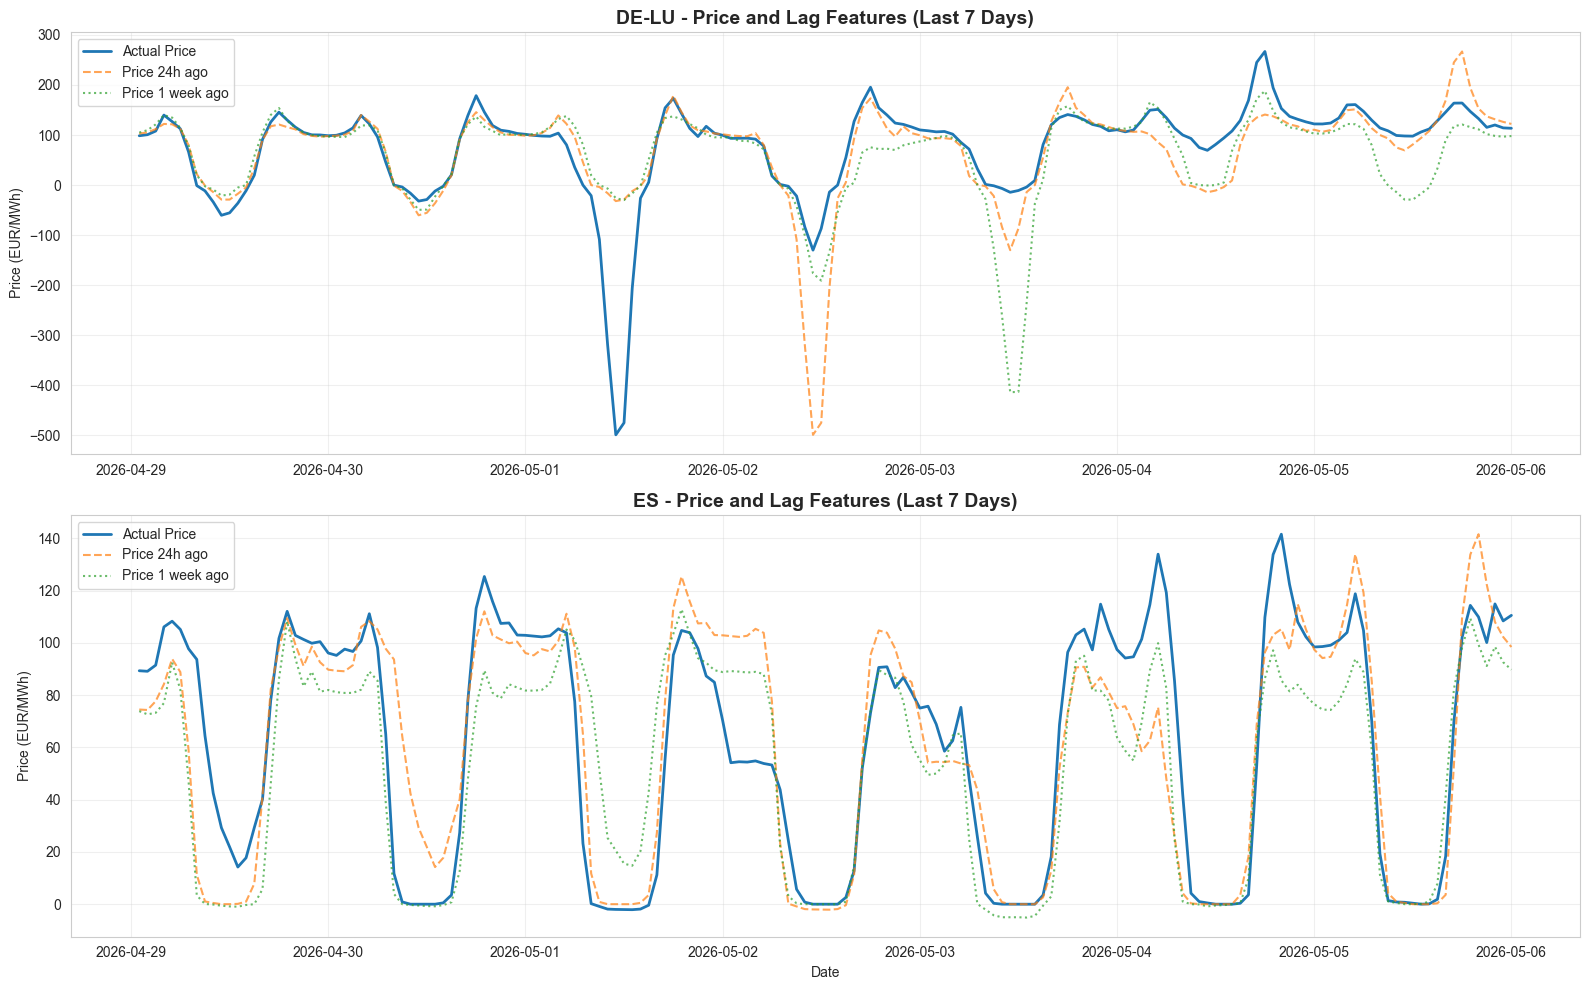

In [8]:
# Plot price with its lags
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

for idx, zone in enumerate(zones):
    df = data_engineered[zone].tail(7*24)  # Last week
    
    axes[idx].plot(df['timestamp'], df['price_eur_mwh'], label='Actual Price', linewidth=2)
    axes[idx].plot(df['timestamp'], df['price_lag_24h'], label='Price 24h ago', alpha=0.7, linestyle='--')
    axes[idx].plot(df['timestamp'], df['price_lag_168h'], label='Price 1 week ago', alpha=0.7, linestyle=':')
    
    axes[idx].set_title(f'{zone} - Price and Lag Features (Last 7 Days)', fontsize=14, fontweight='bold')
    axes[idx].set_ylabel('Price (EUR/MWh)')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

axes[1].set_xlabel('Date')
plt.tight_layout()
plt.savefig('../outputs/plots/feature_eng_price_lags.png', dpi=150, bbox_inches='tight')
plt.show()

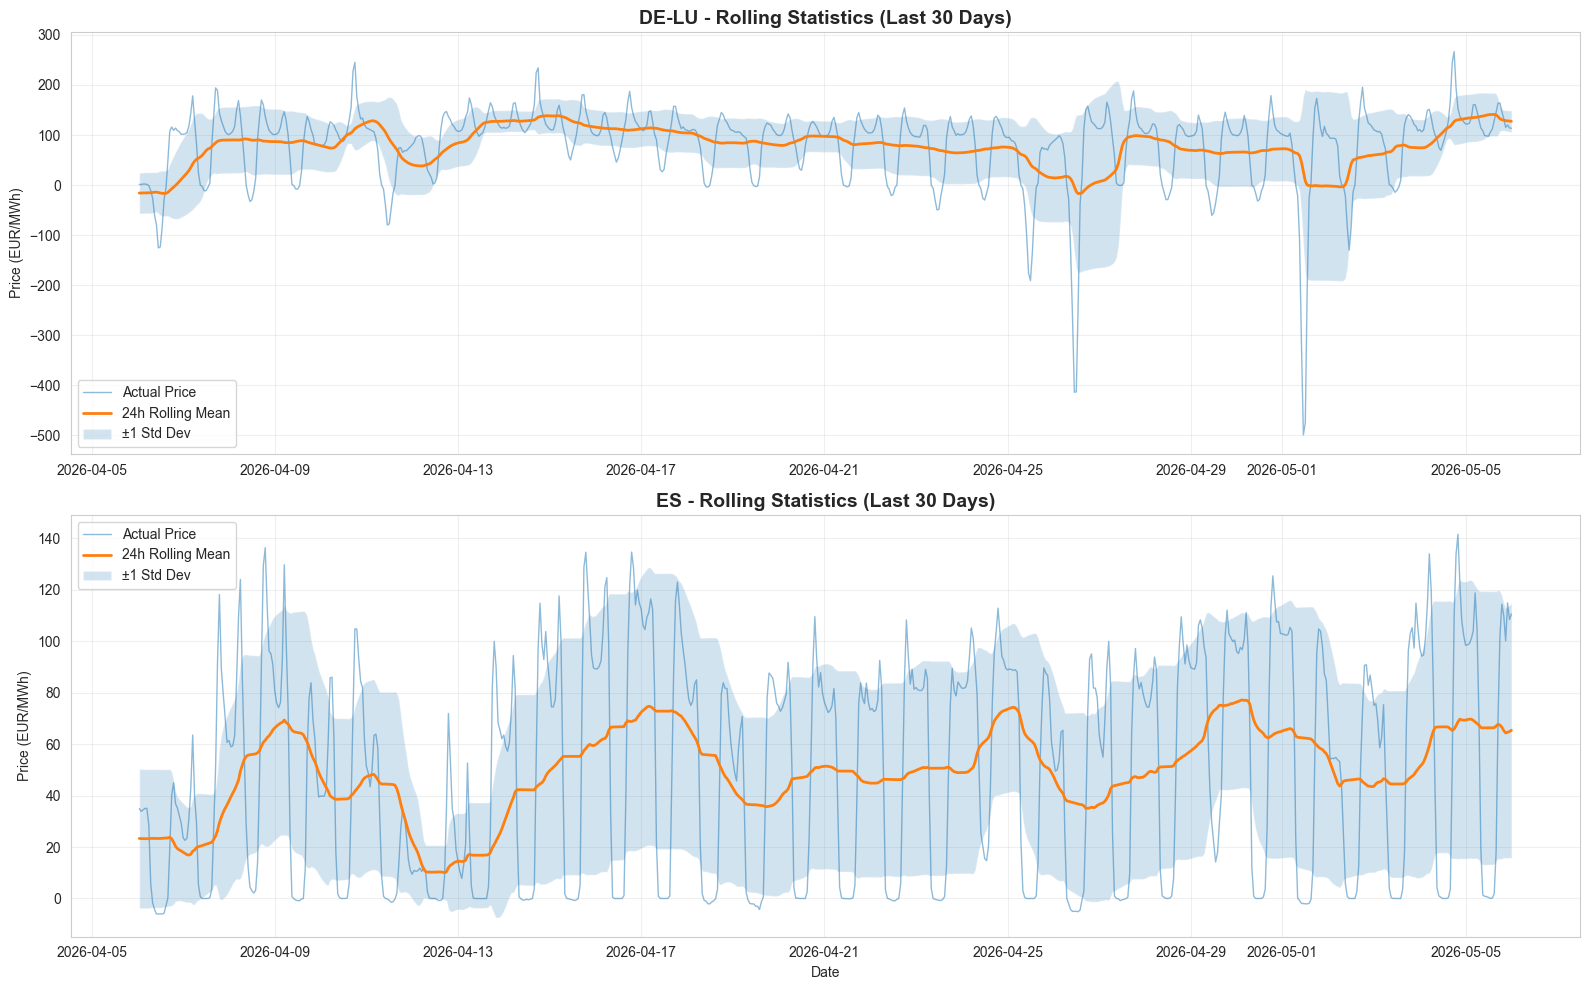

In [9]:
# Plot rolling statistics
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

for idx, zone in enumerate(zones):
    df = data_engineered[zone].tail(30*24)  # Last 30 days
    
    axes[idx].plot(df['timestamp'], df['price_eur_mwh'], label='Actual Price', alpha=0.5, linewidth=1)
    axes[idx].plot(df['timestamp'], df['price_rolling_mean_24h'], label='24h Rolling Mean', linewidth=2)
    axes[idx].fill_between(df['timestamp'],
                          df['price_rolling_mean_24h'] - df['price_rolling_std_24h'],
                          df['price_rolling_mean_24h'] + df['price_rolling_std_24h'],
                          alpha=0.2, label='±1 Std Dev')
    
    axes[idx].set_title(f'{zone} - Rolling Statistics (Last 30 Days)', fontsize=14, fontweight='bold')
    axes[idx].set_ylabel('Price (EUR/MWh)')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

axes[1].set_xlabel('Date')
plt.tight_layout()
plt.savefig('../outputs/plots/feature_eng_rolling_stats.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Feature Correlation Analysis

In [10]:
# Select top features correlated with price
for zone in zones:
    print(f"\n{'='*60}")
    print(f"{zone} - Top 20 Features Correlated with Price")
    print(f"{'='*60}")
    
    df = data_engineered[zone].copy()
    
    # Calculate correlations
    correlations = df.corr()['price_eur_mwh'].drop('price_eur_mwh').abs().sort_values(ascending=False)
    
    print("\nTop 20 Features:")
    for i, (feat, corr) in enumerate(correlations.head(20).items(), 1):
        print(f"  {i:2d}. {feat:40s} : {corr:.4f}")


DE-LU - Top 20 Features Correlated with Price

Top 20 Features:
   1. price_lag_1h                             : 0.9261
   2. residual_load_mw                         : 0.8283
   3. residual_load_ratio                      : 0.8159
   4. residual_load_lag_1h                     : 0.7910
   5. price_lag_2h                             : 0.7612
   6. renewable_share_pct                      : 0.7583
   7. price_rolling_mean_6h                    : 0.7531
   8. total_flexible_mw                        : 0.7428
   9. supply_demand_ratio                      : 0.7288
  10. net_storage_mw                           : 0.7241
  11. total_mustrun_mw                         : 0.7074
  12. total_renewable_mw                       : 0.7036
  13. pumped_storage_consumption_mw            : 0.7025
  14. price_rolling_max_6h                     : 0.6984
  15. renewable_lag_1h                         : 0.6918
  16. total_fossil_mw                          : 0.6683
  17. price_rolling_min_6h             

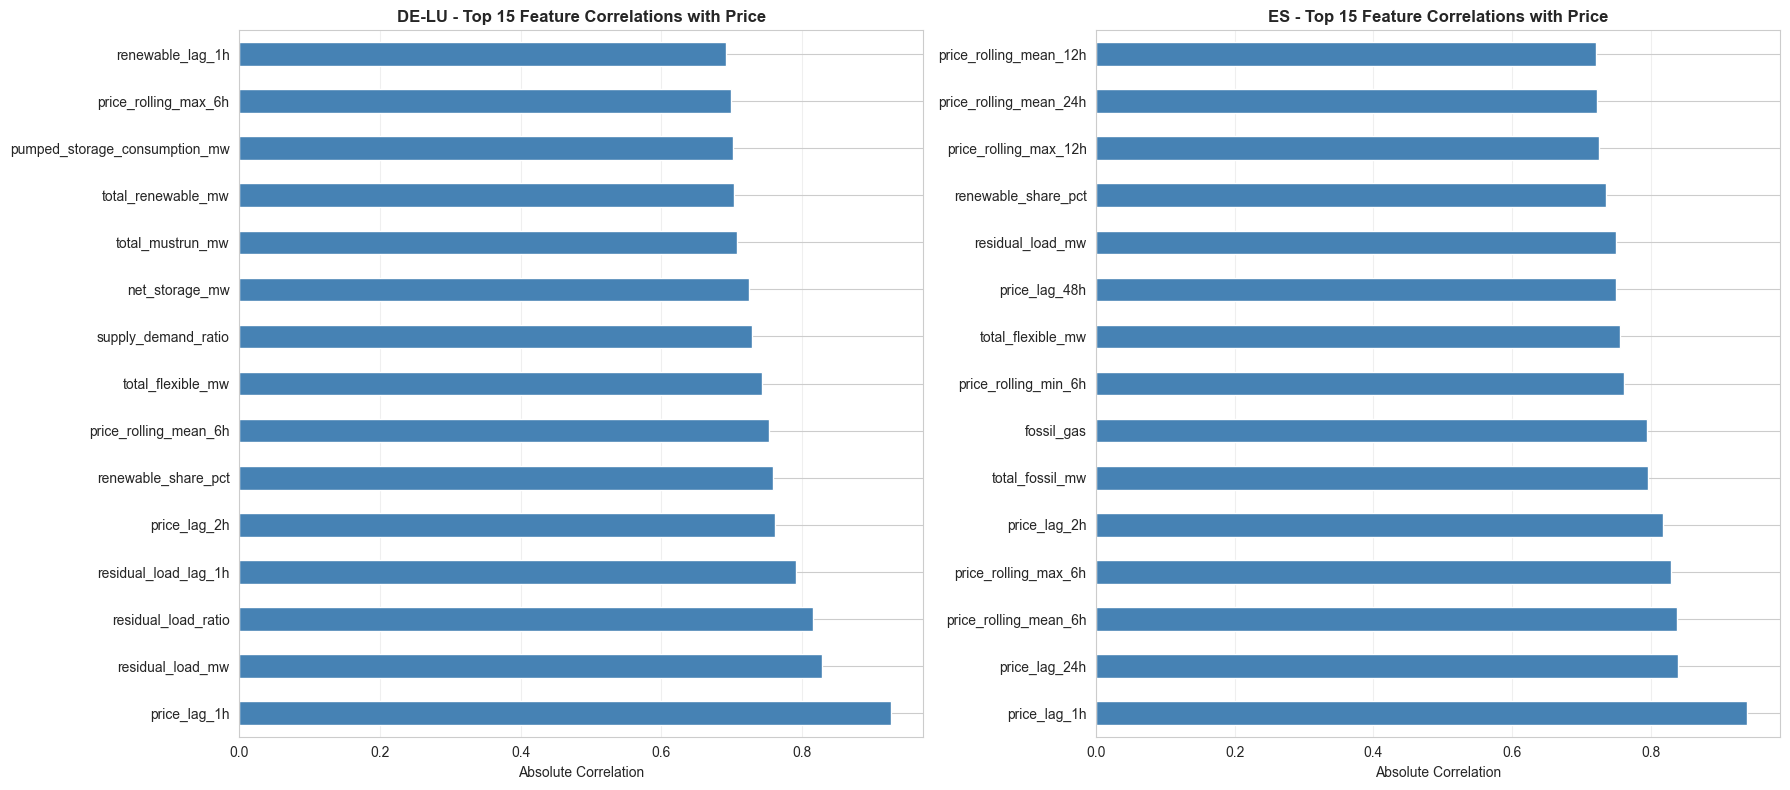

In [11]:
# Visualize top correlations
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for idx, zone in enumerate(zones):
    df = data_engineered[zone].copy()
    
    # Get top 15 correlations
    correlations = df.corr()['price_eur_mwh'].drop('price_eur_mwh').abs().sort_values(ascending=False).head(15)
    
    # Plot
    correlations.plot(kind='barh', ax=axes[idx], color='steelblue')
    axes[idx].set_title(f'{zone} - Top 15 Feature Correlations with Price', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Absolute Correlation')
    axes[idx].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('../outputs/plots/feature_eng_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Prepare Training Data

In [12]:
# Prepare X, y for both zones
training_data = {}

for zone in zones:
    print(f"\n{'='*60}")
    print(f"Preparing Training Data for {zone}")
    print(f"{'='*60}")
    
    X, y = prepare_training_data(
        data_engineered[zone],
        target_col='price_eur_mwh',
        drop_na=True
    )
    nan_counts = X.isna().sum()
    print(f"   Target range: {y.min():.2f} to {y.max():.2f} EUR/MWh")
    print(nan_counts[nan_counts > 0].sort_values(ascending=False))

    # Und Target?
    print(f"Target NaN: {y.isna().sum()} / {len(y)}")
    
    training_data[zone] = {'X': X, 'y': y}
    
    print(f"\n📊 Training Data Summary:")
    print(f"   Samples: {len(X):,}")
    print(f"   Features: {len(X.columns)}")
    print(f"   Target range: {y.min():.2f} to {y.max():.2f} EUR/MWh")
    print(f"   Target mean: {y.mean():.2f} EUR/MWh")
    print(f"   Target std: {y.std():.2f} EUR/MWh")


Preparing Training Data for DE-LU
✅ Training data prepared: 2833 samples, 100 features
   Target range: -499.00 to 310.86 EUR/MWh
Series([], dtype: int64)
Target NaN: 0 / 2833

📊 Training Data Summary:
   Samples: 2,833
   Features: 100
   Target range: -499.00 to 310.86 EUR/MWh
   Target mean: 96.07 EUR/MWh
   Target std: 56.04 EUR/MWh

Preparing Training Data for ES
✅ Training data prepared: 2794 samples, 100 features
   Target range: -9.82 to 247.15 EUR/MWh
Series([], dtype: int64)
Target NaN: 0 / 2794

📊 Training Data Summary:
   Samples: 2,794
   Features: 100
   Target range: -9.82 to 247.15 EUR/MWh
   Target mean: 42.61 EUR/MWh
   Target std: 44.61 EUR/MWh


## 7. Save Feature-Engineered Data

In [13]:
# Save feature-engineered data for modeling
output_dir = Path('../data/engineered')
output_dir.mkdir(parents=True, exist_ok=True)

# Timezone mapping for proper offset preservation
TIMEZONE = {
    'DE-LU': 'Europe/Berlin',
    'ES': 'Europe/Madrid'
}

for zone in zones:
    # Save full feature-engineered data with timezone preservation
    output_file = output_dir / f'{zone.lower()}_features.csv'
    df_to_save = data_engineered[zone].copy()
    
    # Convert UTC to local timezone and format with explicit offset
    if 'timestamp' in df_to_save.columns:
        df_to_save['timestamp'] = df_to_save['timestamp'].dt.tz_convert(TIMEZONE[zone])
        df_to_save['timestamp'] = df_to_save['timestamp'].apply(lambda x: x.isoformat())
    
    df_to_save.to_csv(output_file, index=False)
    print(f"✅ Saved {zone} features to {output_file}")
    
    # Save training data (X, y) - no timestamp column here
    X = training_data[zone]['X']
    y = training_data[zone]['y']
    
    # Combine X and y for easy loading
    train_df = X.copy()
    train_df['price_eur_mwh'] = y.values
    
    output_file = output_dir / f'{zone.lower()}_training_data.csv'
    train_df.to_csv(output_file, index=False)
    print(f"✅ Saved {zone} training data to {output_file}")

print("\n✅ All feature-engineered data saved!")

✅ Saved DE-LU features to ..\data\engineered\de-lu_features.csv
✅ Saved DE-LU training data to ..\data\engineered\de-lu_training_data.csv
✅ Saved ES features to ..\data\engineered\es_features.csv
✅ Saved ES training data to ..\data\engineered\es_training_data.csv

✅ All feature-engineered data saved!


## 8. Feature Engineering Summary

In [14]:
print("\n" + "="*80)
print("FEATURE ENGINEERING SUMMARY")
print("="*80)

for zone in zones:
    print(f"\n{zone}:")
    print("-" * 40)
    
    groups = engineers[zone].get_feature_importance_groups()
    
    print(f"\nFeature Groups:")
    for group_name, features in groups.items():
        if features:
            print(f"  {group_name:15s}: {len(features):3d} features")
    
    print(f"\nTotal Features: {len(engineers[zone].get_feature_names())}")
    print(f"Training Samples: {len(training_data[zone]['X']):,}")

print("\n" + "="*80)
print("\n✅ Feature Engineering Complete!")
print("\nNext Steps:")
print("  1. Model Development - Train XGBoost/LightGBM models")
print("  2. Quantile Regression - Implement p025, p50, p975 predictions")
print("  3. Model Evaluation - Test on validation set")
print("  4. Generate Predictions - For evaluation window")


FEATURE ENGINEERING SUMMARY

DE-LU:
----------------------------------------

Feature Groups:
  temporal       :  10 features
  lag            :  16 features
  rolling        :  20 features
  differential   :   8 features
  interaction    :   4 features
  cyclical       :   6 features
  raw            :  37 features

Total Features: 101
Training Samples: 2,833

ES:
----------------------------------------

Feature Groups:
  temporal       :  10 features
  lag            :  16 features
  rolling        :  20 features
  differential   :   8 features
  interaction    :   4 features
  cyclical       :   6 features
  raw            :  37 features

Total Features: 101
Training Samples: 2,794


✅ Feature Engineering Complete!

Next Steps:
  1. Model Development - Train XGBoost/LightGBM models
  2. Quantile Regression - Implement p025, p50, p975 predictions
  3. Model Evaluation - Test on validation set
  4. Generate Predictions - For evaluation window
